In [24]:
%load_ext autoreload
%autoreload 2
from api_keys import OPENAI_API_KEY, GOOGLE_API_KEY
import os 
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
import numpy as np
import jax
import scipy
import sklearn


import matplotlib
import matplotlib.pyplot as plt
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

import jax.numpy as jnp
import sciexplorer
from sciexplorer.runs.linear_exploration import run_exploration


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
class BlackBoxSystem():
    """Lotka-Volterra system describing predator-prey dynamics as black box simulator."""
    
    def __init__(self, a=1.0, b=0.1, c=1.5, d=0.075, dt=0.1, num_steps=1000, steps_per_timestep=10):
        self.a = a  # Prey growth rate
        self.b = b  # Predation rate
        self.c = c  # Predator death rate
        self.d = d  # Predator reproduction rate
        self.dt = dt # Time step for integration
        self.num_steps = num_steps # Number of time steps to simulate
        self.steps_per_timestep = steps_per_timestep # Number of internal solver steps per time step (not used in this simple Euler method)

    def step(self, state):
        """Perform one time step using Euler's method."""
        prey, predator = state
        for _ in range(self.steps_per_timestep):
            dprey = (self.a * prey - self.b * prey * predator) * (self.dt / self.steps_per_timestep)
            dpredator = (self.d * prey * predator - self.c * predator) * (self.dt / self.steps_per_timestep)
            prey += dprey
            predator += dpredator
        return np.array([prey, predator])
    
    def observe_dynamics(self, init0:float, init1:float) -> dict:
        # This is a tool. Its docstring and typehints will be automatically parsed to create the tool description for the agent.
        # Therefore, we cannot provide any hints about the system here.
        # Additionally, the final tool description will automatically ask the agent to provide a label under which the result should be saved.
        # Tools always need to return dictionaries!
        """Observe the dynamics of the system given initial conditions.
        Args:
            init0: Initial condition one.
            init1: Initial condition two
        Returns of dict of the form:
            states (np.ndarray): Array containing the states at each time step.
            times (np.ndarray): Array containing the time points.
        """
        states = [np.array([init0, init1])]
        for _ in range(self.num_steps):
            new_state = self.step(states[-1])
            states.append(new_state)
        return {"states": np.array(states), "times": np.arange(len(states))*self.dt}
    
    def save_result(self, result:str) -> dict:
        # This is the result tool. It can return any type. 
        # Its result will not be communicated to the agent, but instead saved for the user.
        # The agent may see Exceptions raised by this tool and asked to try again.
        # Its docstring and typehints will be automatically parsed to create the tool description for the agent.
        """Save your predicted equation of motion for the system.
        Args:
            result: python code as a string the defines the following function:
                def equation_of_motion(state: np.ndarray) -> np.ndarray:
                    # state is a numpy array of shape (2,) containing the current state [s0, s1]
                    # The function should return a numpy array of shape (2,) containing the time derivative [ds0/dt, ds1/dt]
                    return np.array([ds0_dt, ds1_dt])
        Returns:
            Message that the result was saved.
        """
        # You may add some code to automaticcally validate the result here.
        self.last_result = {"predicted_eom": result}
        return result



In [26]:
model = ChatOpenAI(model="gpt-5")
#model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

# set model type for API-specific printing and image handling
sciexplorer.utils.model_specifics.MODEL_TYPE = "openai"  # or "gemini"

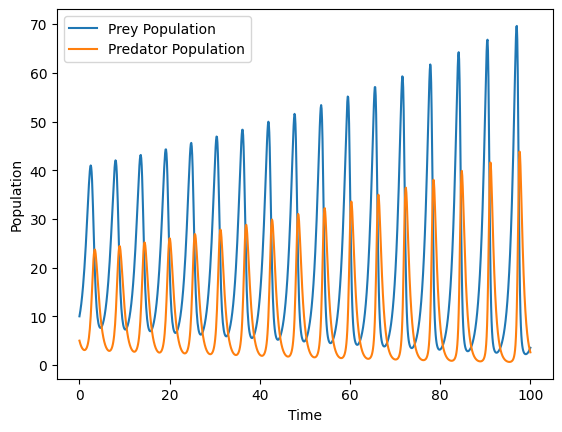

In [27]:
experiment = BlackBoxSystem()
result = experiment.observe_dynamics(init0=10.0, init1=5.0)
plt.plot(result["times"], result["states"][:,0], label='Prey Population')
plt.plot(result["times"], result["states"][:,1], label='Predator Population')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()


In [28]:
system_prompt = """You are a cautious and curious scientist.
You visualize your data and results before fitting.
<tool_preambles>
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>"""
first_message = """
In this system, you can observe the population dynamics of two species in an experimental biological system.
Figure out the equations of motion governing the dynamics of this system."""

In [29]:
from sciexplorer.tools.tool_utils import exec_with_error_line
# example of a tool to execute arbitrary code (reproduced from sciexplorer.tools.coding_tools)
def execute_code(_fields:dict, code: str) -> dict:
    # The _fields dictionary automatically contains all previously tool results.
    # It is automatically populated by the framework and the agent is not asked to provide it as an argument.
    """ Evaluate python code.
        This code can be e.g. be used to transform the previously saved fields or to calculate or save new fields.
        The following variables are available during evaluation:
            all previosuly saved fields with their previously stated result_key as variable names (as global variables).
            jax: jax for numerical operations.
            jnp: jax.numpy for numerical operations.
            np: numpy for numerical operations.
            scipy: scipy for numerical operations including optimization and solving differential equations.
            sklearn: scikit-learn.
        IMPORTANT: Your code must set the variable 'result' to a dictionary in the end which should contain the newly generated data, for example: result={'<result_key>': <data>, ...}.
        Args:
            code: python code that sets the result variable to a dictionary containing some newly generated data.
        Returns:
            the result dictionary.
        """
    globals_dict = _fields | {'result':None, 'jax':jax, 'jnp': jnp, 'np':np, 'scipy':scipy, 'sklearn': sklearn}
    globals_dict = exec_with_error_line(code, globals_dict) # execute the code with error line reporting
    if globals_dict['result'] is None:
        # You should raise Exceptions with descriptive error messages when something goes wrong in tools. 
        # They will be caught and communicated to the agent.
        raise ValueError("The code did not set the result variable. It must be set to a dictionary containing the newly generated data. E.g. result={'<result_key>': <data>, ...}")
    if not isinstance(globals_dict['result'], dict):
        raise ValueError("The result variable must be a dictionary. E.g. result={'<result_key>': <data>, ...}")
    return globals_dict['result']

In [30]:
from sciexplorer.tools.tool_utils import get_image
# tool with image as an output
def plot_from_code(_fields:dict, code: str) -> dict:
    """
    Execute python code that produces a plot from one or more previously saved arrays.
    The following variables are available during evaluation:
        all previosuly saved fields with their previously stated result_key as variable names (as global variables).
    You may use the following libraries:
        matplotlib: for plotting.
        matplotlib.pyplot as plt: for plotting.
        jax: for numerical operations.
        jax.numpy: for numerical operations.
        numpy: for numerical operations.
    Args:
        code: python code that produces a plot (without a plt.show() call!).
    Returns:
        Image
    """
    globals_dict = _fields | {'matplotlib': matplotlib, 'plt': plt, 'jax': jax, 'jnp': jnp, 'np': np}
    globals_dict = exec_with_error_line(code, globals_dict)
    Image = get_image() # special function that captures the current matplotlib figure as an base64 encoded image
    plt.show() # just for the user to see the plot during execution
    return {'image': Image}

In [ ]:
import functools
from sciexplorer.tools.tool_utils import run_with_timeout # wrapper to add timeouts to tool calls
timeout = 300 # seconds

final_state = run_exploration(
        model = model, # The language model to use
        initial_message = first_message + "\nEach tool has a maximum runtime of " + str(timeout) + " seconds and is automatically terminated if it exceeds this limit.", # The initial message to the agent
        result_tool = experiment.save_result, # The tool to save the final result
        system_message = system_prompt, # The system prompt to guide the agent's behavior
        # List of messages to send to the agent in between iterations, will be cycled through if more iterations than messages
        intermediate_message_list=['Go on exploring the system or save your result if you cannot improve it anymore.'],
        max_iterations=5, # Maximum number of iterations to run
        max_tool_uses=18, # Maximum number of tool uses
        tools=[experiment.observe_dynamics, execute_code, plot_from_code], # tools to be used by the agent
        initial_fields=None, # Initial fields available eg. in the execute_code tool
        add_tools_to_fields = False, # Whether to add all tools as callable fields to the _fields dictionary, e.g. to call them from execute_code
        save_path= './example_results', # Path to save the results
        # Wrapper to apply to each tool call, in this case to add a timeout of 300 seconds.
        # Has to have the signature tool_wrapper(tool_function, inputs) (the tool_function should be called with tool_function(inputs))
        # This wrapper is only applied to direct tool calls, not to tools called from within other tools.
        tool_wrapper = functools.partial(run_with_timeout, timeout=timeout),
        print_intermediate=True, # Whether to print intermediate messages
        ask_for_final_message_str='Please summarize your exploration.', # Final message to ask the agent after the result tool was called.
        print_long_arrays=False, # Whether to print long arrays into the agents context (as opposed to saving them and providing a summary only)
        invoke_kwargs={'reasoning': {'effort': "low",'summary': "auto"}, #kwargs passed when calling the model
                       'verbosity': 'high'},
        add_to_saved_dict = {'timeout': timeout}, # additional information to add to the saved dictionary
        add_to_save_name = "", # additional string to add to the save name
        inbuilt_tools = None, # which inbuilt tools provided by the model provider to use. E.g. [{'type': 'web_search'}, ] for OpenAI
)

--binding tools ['observe_dynamics', 'execute_code', 'plot_from_code', 'save_result']--
SYSTEM TEXT: You are a cautious and curious scientist.
You visualize your data and results before fitting.
<tool_preambles>
Before calling tools:
- Describe why you want to call the tool and what you expect to learn from it.
</tool_preambles>
HUMAN TEXT: 
In this system, you can observe the population dynamics of two species in an experimental biological system.
Figure out the equations of motion governing the dynamics of this system.
Each tool has a maximum runtime of 300 seconds and is automatically terminated if it exceeds this limit.
The results of all tool calls will be stored (using the result_label) and are available later.
You have 5 steps remaining and can still call up to 18 tools.
Go on exploring the system or save your result if you cannot improve it anymore.


KeyboardInterrupt: 